# Exercise 2: K-Means Algorithm

In this exercise, we will delve into the world of customer segmentation using the "Bank Marketing" dataset. This dataset provides a rich source of information about a bank's marketing campaigns, customer demographics, and the outcomes of those campaigns. By applying K-means clustering to this dataset, we will uncover natural groupings or segments within the customer data, enabling us to tailor our marketing strategies, enhance customer relations, and make data-driven decisions.

The dataset is taken from https://archive.ics.uci.edu/dataset/222/bank+marketing. However, the "bank-200.csv" (200x17) dataset, which we provide only contains a portion of the original dataset from "bank.csv". You can refer the link above to read more on the information regarding each features in the dataset.

Your task is to build a model using K-Means based on this particular dataset using the 'age' and 'balance' features. The process should include steps like data exploration, cleaning (if necessary), model building, and etc. 

## Task 1 - Data Exploration
- Load the dataset and perform basic data exploration.
- Clean the dataset if necessary.

In [1]:
# Import the libraries

import os
from collections import OrderedDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns


import warnings
# Ignore FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Ignore UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

# import dataset
df = pd.read_csv('bank-200.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        200 non-null    int64 
 1   job        200 non-null    object
 2   marital    200 non-null    object
 3   education  200 non-null    object
 4   default    200 non-null    object
 5   balance    200 non-null    int64 
 6   housing    200 non-null    object
 7   loan       200 non-null    object
 8   contact    200 non-null    object
 9   day        200 non-null    int64 
 10  month      200 non-null    object
 11  duration   200 non-null    int64 
 12  campaign   200 non-null    int64 
 13  pdays      200 non-null    int64 
 14  previous   200 non-null    int64 
 15  poutcome   200 non-null    object
 16  y          200 non-null    object
dtypes: int64(7), object(10)
memory usage: 26.7+ KB


In [2]:
print("     NULL        ")
print(df.isnull().sum())
print("")
print("     DUPLICATES        ")
print(df.duplicated().sum())

     NULL        
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

     DUPLICATES        
0


## Task 2 - Data Visualization
- Perform some basic data visualization on the dataset to gain more insight on the dataset.

In [3]:
numeric_df = df.iloc[:, [0, 5, 9, 11, 12, 13, 14]]
numeric_df

,age,balance,day,duration,campaign,pdays,previous
0,30,1787,19,79,1,-1,0
1,33,4789,11,220,1,339,4
2,35,1350,16,185,1,330,1
3,30,1476,3,199,4,-1,0
4,59,0,5,226,1,-1,0
...,...,...,...,...,...,...,...
195,57,39,30,354,3,-1,0
196,27,5563,30,435,2,-1,0
197,38,1,21,152,2,-1,0
198,42,782,3,285,1,-1,0


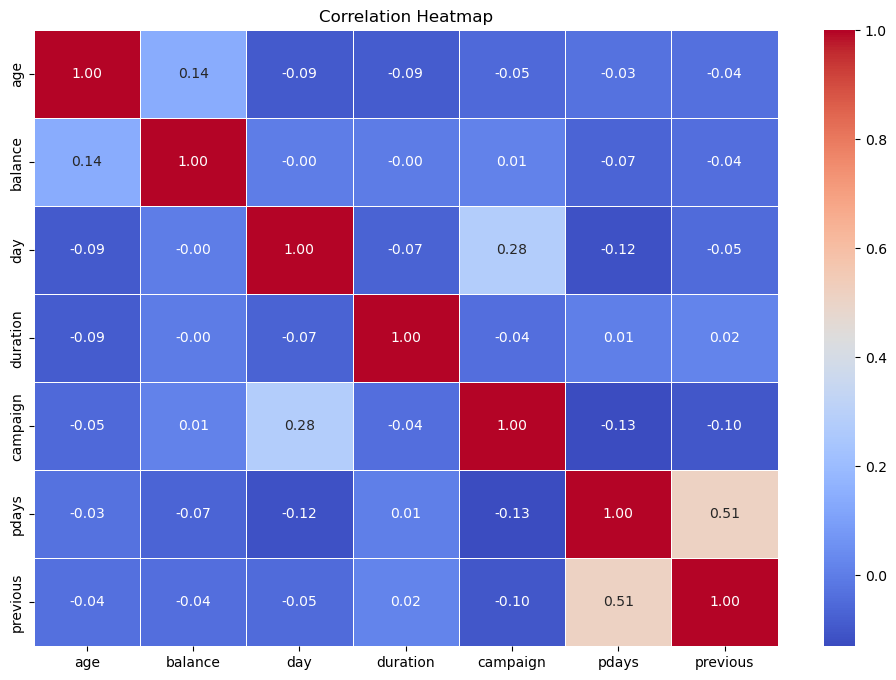

In [4]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

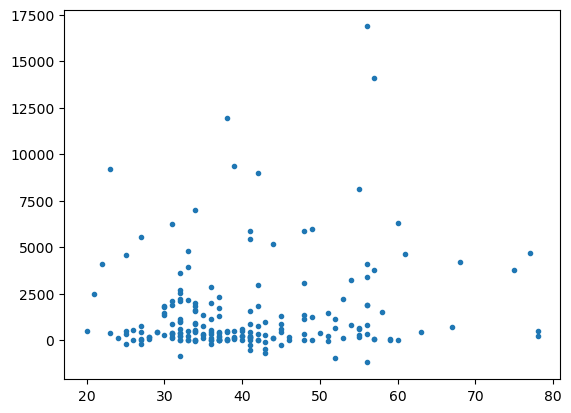

In [5]:
plt.scatter(numeric_df['age'], numeric_df['balance'], marker= '.')

## Task 3 - Elbow Method
- Find the optimal number of clusters using the elbow method.
- Visualize the elbow plot.

In [6]:
# just age and balance according to the question
iloced_df = df.iloc[:, [0, 5]]

stdscaler = StandardScaler()
stdscaler.fit(iloced_df)
transformed_df = stdscaler.transform(iloced_df)
scaled_df = pd.DataFrame(transformed_df, columns=iloced_df.columns)

k_range = range(1,21)
k_wcss = []
for knumber in k_range:
    kmeans = KMeans(knumber)
    kmeans.fit(scaled_df)
    k_wcss.append(kmeans.inertia_)

kmeans_df = pd.DataFrame(OrderedDict(
    {"k_number": k_range,
     "k_wcss": k_wcss}
))
kmeans_df

,k_number,k_wcss
0,1,400.000000
1,2,247.187395
2,3,140.238812
3,4,112.777425
4,5,88.164187
5,6,72.800592
6,7,64.869496
7,8,53.959360
8,9,43.191463
9,10,37.335799


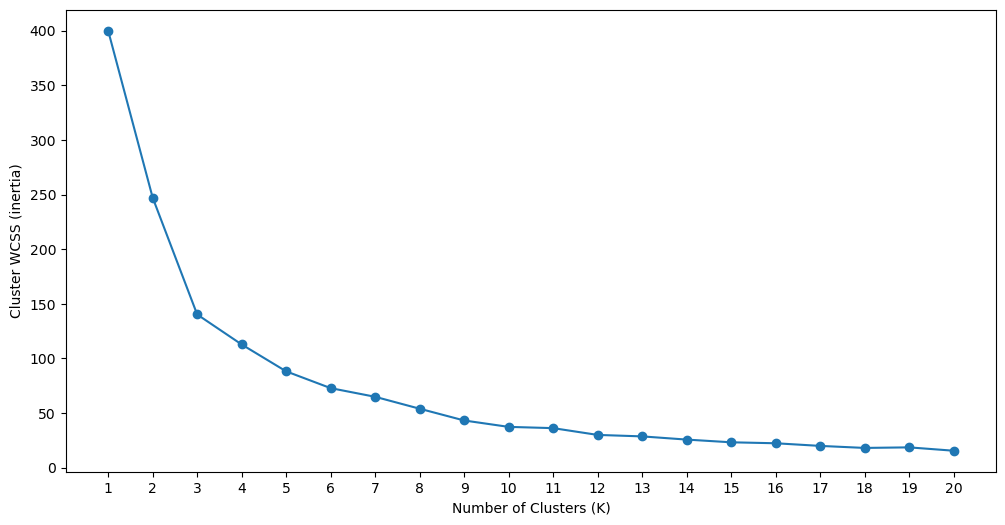

In [7]:
plt.figure(figsize=(12,6))
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Cluster WCSS (inertia)')
plt.xticks(np.arange(min(kmeans_df.k_number),
                     max(kmeans_df.k_number)+1,
                     1.0))
plt.plot(kmeans_df.k_number,
         kmeans_df.k_wcss,
         marker = "o")

## Task 4 - Model Building
- Build the model based on K-means using the optimal number of clusters identified earlier.
- Then visualize and show the clusters.

In [8]:
kmeans = KMeans(n_clusters=11,random_state=10)
kmeans_labels = kmeans.fit_predict(scaled_df)
df['Clusters'] = kmeans_labels
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        200 non-null    int64 
 1   job        200 non-null    object
 2   marital    200 non-null    object
 3   education  200 non-null    object
 4   default    200 non-null    object
 5   balance    200 non-null    int64 
 6   housing    200 non-null    object
 7   loan       200 non-null    object
 8   contact    200 non-null    object
 9   day        200 non-null    int64 
 10  month      200 non-null    object
 11  duration   200 non-null    int64 
 12  campaign   200 non-null    int64 
 13  pdays      200 non-null    int64 
 14  previous   200 non-null    int64 
 15  poutcome   200 non-null    object
 16  y          200 non-null    object
 17  Clusters   200 non-null    int32 
dtypes: int32(1), int64(7), object(10)
memory usage: 27.5+ KB


In [9]:
kmeans_profile = df.iloc[:,[0,5,17]].groupby(['Clusters'],
                                             as_index=False).mean()
kmeans_profile

,Clusters,age,balance
0,0,40.186441,248.203390
1,1,55.222222,3130.000000
2,2,35.500000,9892.500000
3,3,33.120000,2031.800000
4,4,51.200000,6296.200000
5,5,53.689655,393.655172
6,6,31.888889,5280.444444
7,7,30.442308,316.384615
8,8,74.333333,474.666667
9,9,56.500000,15483.000000


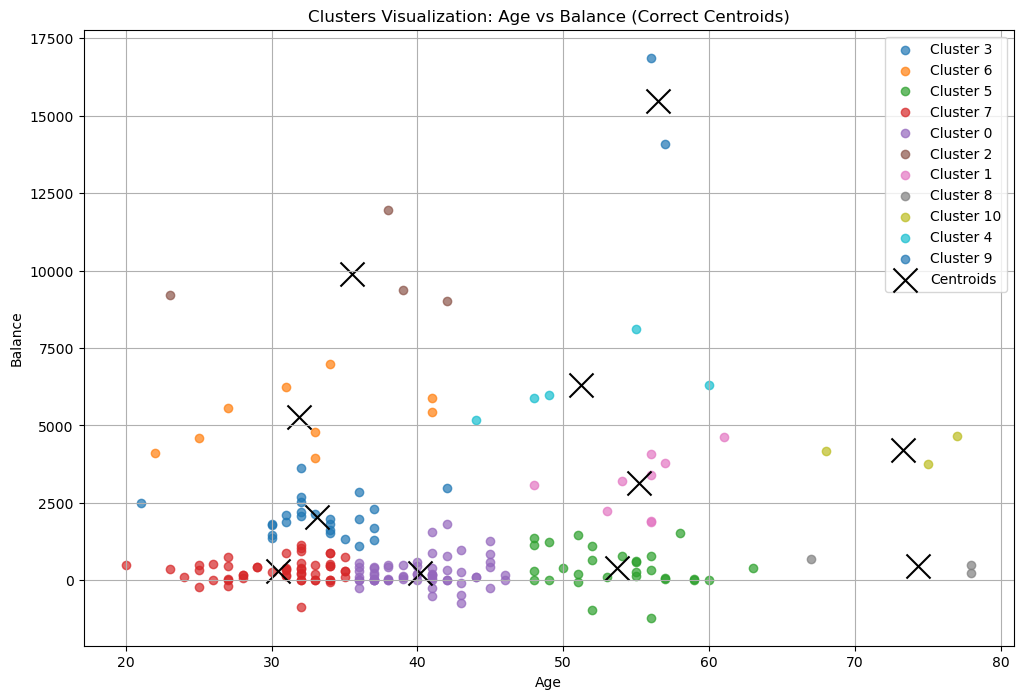

In [10]:
# Inverse transform the centroids to map them back to the original feature space
centroids_original = stdscaler.inverse_transform(kmeans.cluster_centers_)

# Scatter plot for the clusters
plt.figure(figsize=(12, 8))
for cluster in df['Clusters'].unique():
    cluster_data = df[df['Clusters'] == cluster]
    plt.scatter(cluster_data['age'], cluster_data['balance'], label=f"Cluster {cluster}", alpha=0.7)

# Add the centroids (now in the original scale)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], s=300, c='black', marker='x', label='Centroids')

# Plot aesthetics
plt.title("Clusters Visualization: Age vs Balance (Correct Centroids)")
plt.xlabel("Age")
plt.ylabel("Balance")
plt.legend()
plt.grid()
plt.show()